In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import functools as ft

In [3]:
ampi = pd.read_csv(r"C:\Users\varia\OneDrive\Dragon Hoard's Index\Datasets\Cleaned Datasets\AMPI USD Converted.xls")
be = pd.read_csv(r"C:\Users\varia\OneDrive\Dragon Hoard's Index\Datasets\Cleaned Datasets\BE100 Index 1000 Initial Price.xls")
pcgs = pd.read_csv(r"C:\Users\varia\OneDrive\Dragon Hoard's Index\Datasets\Cleaned Datasets\PCGS3000 Index Monthly 2026 Fixed.xls")
magic = pd.read_csv(r"C:\Users\varia\OneDrive\Dragon Hoard's Index\Datasets\Cleaned Datasets\MtG Reserved List Monthly.xls")

In [4]:
be = be.rename(columns = {'datetime':'Date', '0':'BE Price'})
pcgs = pcgs.rename(columns = {'Unnamed: 0':'Date', 'Price':'PCGS Price'})
ampi = ampi.rename(columns = {'Unnamed: 0':'Date', 'Index (1000 in 1978)':'AMPI Price'})
magic = magic.rename(columns = {'Price':'Reserved List Price'})

In [5]:
# Convert to datetime index
ampi['Date'] = pd.to_datetime(ampi['Date'])
be['Date'] = pd.to_datetime(be['Date'])
pcgs['Date'] = pd.to_datetime(pcgs['Date'])
magic['Date'] = pd.to_datetime(magic['Date'])

In [6]:
'''
items = [ampi, be, pcgs, magic]
for df in items:
    df.set_index('Date', inplace = True)
'''
# get rid of 0 and nan at start and end of ampi data
ampi = ampi[1:-1]

In [7]:
# Make into df with only ampi index price
ampi_series = ampi.drop(columns = ['AMPI UMV', 'Smoothed Index (0.2 alpha)'])

## Make Collective DF With All Prices

In [8]:
dfs = [pcgs, ampi_series, magic, be]
df = ft.reduce(lambda left, right: pd.merge(left, right, on='Date', how='outer'), dfs)

In [9]:
df['Date'] = pd.to_datetime(df['Date'])
df = df.set_index('Date')

In [10]:
df = df[:-2]

In [11]:
df.tail()

,PCGS Price,AMPI Price,Reserved List Price,BE Price
Date,,,,
2025-09-01,73418.55,73355.760048,101339.32,8091.794486
2025-10-01,73293.46,70865.074300,104442.25,8179.303189
2025-11-01,73238.54,81802.282929,100244.11,8216.106952
2025-12-01,73294.78,78592.155876,96629.54,8393.465441
2026-01-01,73153.12,79277.664739,94538.49,8438.100802


In [12]:
df.to_csv('Indices df.csv')

**NEED TO CALCULATE HISTORICAL MARKET SIZE BASED ON PCT CHANGE IN INDEX PRICE BY BACKTRACKING STARTING FROM 2025 MARKET SIZE**

## Market Size Calculations

In [13]:
pct = df.copy().pct_change().shift(-1)

In [14]:
pct.tail()

,PCGS Price,AMPI Price,Reserved List Price,BE Price
Date,,,,
2025-09-01,-0.001704,-0.033954,0.030619,0.010814
2025-10-01,-0.000749,0.154338,-0.040196,0.004500
2025-11-01,0.000768,-0.039243,-0.036058,0.021587
2025-12-01,-0.001933,0.008722,-0.021640,0.005318
2026-01-01,NaN,NaN,NaN,NaN


In [15]:
rev = pct.iloc[::-1]
rev = rev.fillna(0)

# final values
final_vals = pd.Series({
    'PCGS Price': 15.95/51.05, #16000000000,
    'AMPI Price': 26/51.05, #26000000000,
    'Reserved List Price': 8.1/51.05, #8100000000,
    'BE Price': 1/51.05 #1000000000
}) # divide each by sum of all 48.12

market_size = final_vals / (1 + rev).cumprod()
    
market_size = market_size.iloc[::-1]

# make new column with all columns added then divide each by the sum
market_size['sum'] = market_size.sum(axis = 1)

In [16]:
market_weight = pd.DataFrame()
market_weight['PCGS Price'] = market_size['PCGS Price']/market_size['sum'].copy()
market_weight['AMPI Price'] = market_size['AMPI Price']/market_size['sum'].copy()
market_weight['Reserved List Price'] = market_size['Reserved List Price']/market_size['sum'].copy()
market_weight['BE Price'] = market_size['BE Price']/market_size['sum'].copy()

In [17]:
market_weight.tail()

,PCGS Price,AMPI Price,Reserved List Price,BE Price
Date,,,,
2025-09-01,0.322042,0.483990,0.174676,0.019292
2025-10-01,0.325209,0.472960,0.182105,0.019726
2025-11-01,0.304983,0.512384,0.164037,0.018596
2025-12-01,0.313167,0.505099,0.162241,0.019493
2026-01-01,0.312439,0.509305,0.158668,0.019589


Starting in 2025
- Coin market: **16 billion** averaged from 2 sources
- LEGO: tracked: estimated 705 million in 2024, estimate **1 billion** for 2025
- US Art Market: **26 billion** in 2025 by Art Basel and UBS
- Magic: **8.1 billion** in 2025 average from 2 sources

*Do sensativity test later to test if the innacuracy from the coin and magic affects results*

Earliest Start Date: 1970-02-01
Latest Start Date: 2011-01-01

## Calculate Index Scaled By Market Size

In [18]:
scaled_df = df * market_weight

In [19]:
scaled_df.head(30)

,PCGS Price,AMPI Price,Reserved List Price,BE Price
Date,,,,
1970-02-01,122.840341,NaN,NaN,NaN
1970-03-01,122.840341,NaN,NaN,NaN
1970-04-01,122.840341,NaN,NaN,NaN
1970-05-01,122.840341,NaN,NaN,NaN
1970-06-01,122.840341,NaN,NaN,NaN
1970-07-01,122.840341,NaN,NaN,NaN
1970-08-01,122.840341,NaN,NaN,NaN
1970-09-01,122.840341,NaN,NaN,NaN
1970-10-01,122.840341,NaN,NaN,NaN


In [20]:
print(scaled_df.iloc[95])

PCGS Price             4163.564673
AMPI Price              361.911375
Reserved List Price            NaN
BE Price                       NaN
Name: 1978-01-01 00:00:00, dtype: float64


In [21]:
tomorrow = df.shift(1) # filled rev NA with 0 so use original df
added = df.notna() & tomorrow.isna()
removed = df.isna() * tomorrow.notna()

cmv = (scaled_df*added).sum(axis=1) - (tomorrow*removed).sum(axis=1)
cmv.iloc[0] = 0.0 # set first value to 0 as cmv at t = 0 should be 0
print(cmv.unique())

[  0.         361.91137521 266.16158926   3.25365635]


In [22]:
scaled_df = scaled_df.fillna(0).astype(float)
indexlevel = 100
divisor = scaled_df.iloc[0].sum()/indexlevel
index = pd.Series(0, index = scaled_df.index, dtype = float)

for i,date in enumerate(scaled_df.index):
    mv = scaled_df.iloc[i].sum()
    divisor = divisor +  cmv.iloc[i]/indexlevel
    indexlevel = mv/divisor
    #print(f'index price{indexlevel}')
    index.iloc[i] = indexlevel

In [23]:
index.tail(20)

Date
2024-06-01    64533.126214
2024-07-01    66326.471744
2024-08-01    66353.408397
2024-09-01    67751.145264
2024-10-01    64233.130265
2024-11-01    61294.128446
2024-12-01    59527.726626
2025-01-01    58093.348266
2025-02-01    58661.747521
2025-03-01    58763.251046
2025-04-01    58805.499013
2025-05-01    58785.153253
2025-06-01    58878.004600
2025-07-01    57022.019182
2025-08-01    57737.392866
2025-09-01    57158.479046
2025-10-01    56808.033790
2025-11-01    60010.457700
2025-12-01    58261.698202
2026-01-01    58192.394747
dtype: float64

In [24]:
'''
scaled_df = scaled_df.fillna(0).astype(float)
indexlevel = 50
divisor = scaled_df.iloc[0].sum()/indexlevel
index = pd.Series(0, index = scaled_df.index, dtype = float)

for i,date in enumerate(scaled_df.index):
    mv = scaled_df.iloc[i].sum()
    divisor = divisor +  cmv.iloc[i]/indexlevel
    indexlevel = mv/divisor
    if cmv.iloc[i] != 0:
        print(f'CMV Value:{cmv.iloc[i]}')
        print(f'divisor{divisor}')
    #print(f'index price{indexlevel}')
    index.iloc[i] = indexlevel
'''

"\nscaled_df = scaled_df.fillna(0).astype(float)\nindexlevel = 50\ndivisor = scaled_df.iloc[0].sum()/indexlevel\nindex = pd.Series(0, index = scaled_df.index, dtype = float)\n\nfor i,date in enumerate(scaled_df.index):\n    mv = scaled_df.iloc[i].sum()\n    divisor = divisor +  cmv.iloc[i]/indexlevel\n    indexlevel = mv/divisor\n    if cmv.iloc[i] != 0:\n        print(f'CMV Value:{cmv.iloc[i]}')\n        print(f'divisor{divisor}')\n    #print(f'index price{indexlevel}')\n    index.iloc[i] = indexlevel\n"

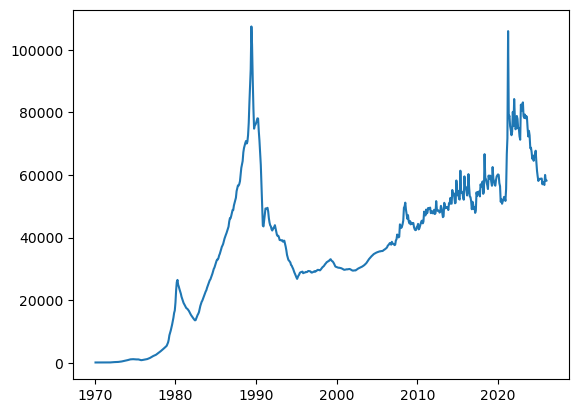

In [25]:
plt.plot(index)
plt.show()

In [26]:
index.to_csv("FIXED_collectible_market_index.csv")

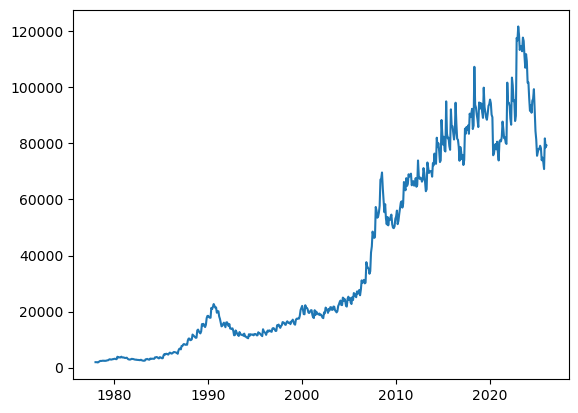

In [27]:
# PCGS Price	AMPI Price	Reserved List Price	BE Price
plt.plot(df['AMPI Price'])
plt.show()

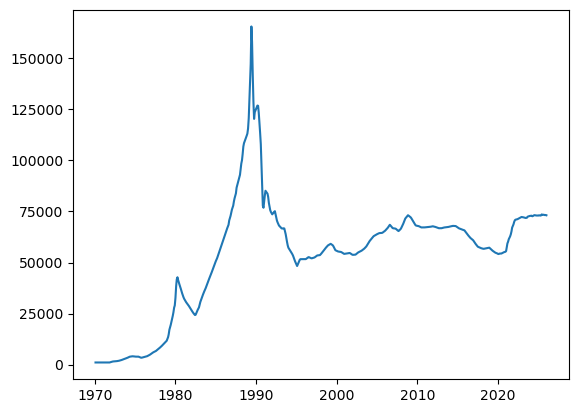

In [28]:
plt.plot(df['PCGS Price'])
plt.show()

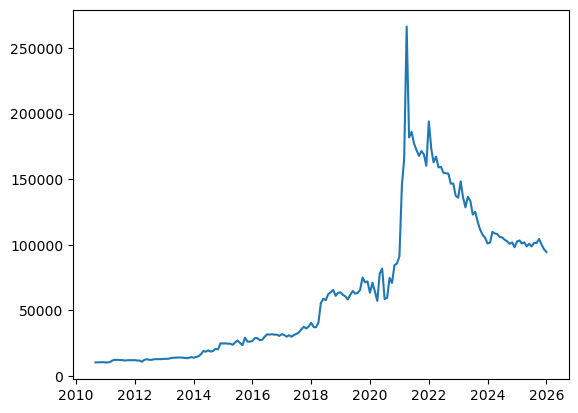

In [29]:
plt.plot(df['Reserved List Price'])
plt.show()

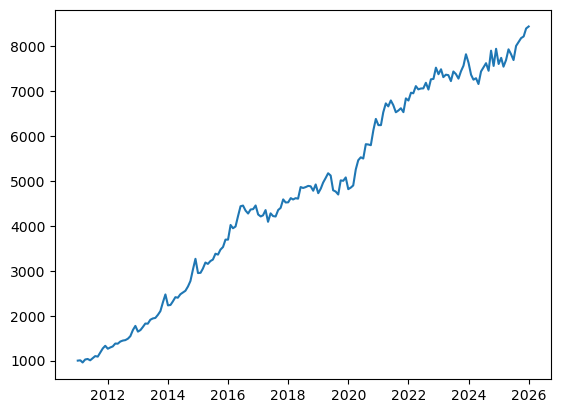

In [30]:
plt.plot(df['BE Price'])
plt.show()